# Decision Tree Learning

Decision tree classifiers are highly interpretable models that break down data by asking a series of questions.

* **Structure:** They start at a **root node**, split the data at **internal nodes** based on specific features (e.g., "Is sepal width $\geq$ 2.8 cm?"), and flow down **branches** until reaching pure **leaf nodes** where a final class label is assigned.
* **Overfitting:** Because decision trees can grow very deep and complex, they easily overfit the training data. Setting a maximum depth limit (pruning) is standard practice.

---

### Maximizing Information Gain (IG)
To decide exactly *where* and *how* to split the data at each node, the tree learning algorithm optimizes an objective function: it seeks to maximize **Information Gain (IG)**.

Information Gain is simply the difference between the impurity of the parent node and the sum of the child node impurities. The lower the impurity of the child nodes, the higher the information gain.

**The Objective Function:**
$$IG(D_p, f) = I(D_p) - \sum_{j=1}^{m} \frac{N_j}{N_p} I(D_j)$$

Since most libraries (like scikit-learn) implement binary decision trees, this usually simplifies to:
$$IG(D_p, f) = I(D_p) - \frac{N_{left}}{N_p}I(D_{left}) - \frac{N_{right}}{N_p}I(D_{right})$$

*(Where $f$ is the splitting feature, $D_p$ and $D_j$ are the parent and child datasets, $I$ is the impurity measure, and $N$ represents the number of examples).*

---

### The 3 Common Impurity Measures ($I$)

To calculate the Information Gain, we need a way to measure the "impurity" ($I$) of a node. There are three common criteria used in binary decision trees:

#### 1. Entropy ($I_H$)
Attempts to maximize the mutual information in the tree. It is $0$ if a node is perfectly pure (all examples belong to one class) and maximal ($1$ in a binary setting) if the classes are perfectly mixed.
$$I_H(t) = - \sum_{i=1}^{c} p(i|t) \log_2 p(i|t)$$

#### 2. Gini Impurity ($I_G$)
A criterion to minimize the probability of misclassification. In practice, Gini impurity and Entropy yield very similar results and have similar graphical shapes. It is often not worth the time to rigorously evaluate both.
$$I_G(t) = 1 - \sum_{i=1}^{c} p(i|t)^2$$

#### 3. Classification Error ($I_E$)
While useful for *pruning* a tree, Classification Error is not recommended for *growing* one. It is less sensitive to changes in the class probabilities of the nodes, meaning it might fail to prefer a split that produces purer nodes compared to Gini or Entropy.
$$I_E(t) = 1 - \max\{p(i|t)\}$$

> **Note on $p(i|t)$:** This represents the proportion of examples that belong to class $i$ for a particular node $t$.

### 1. Visualize the entropy values for different class distributions.


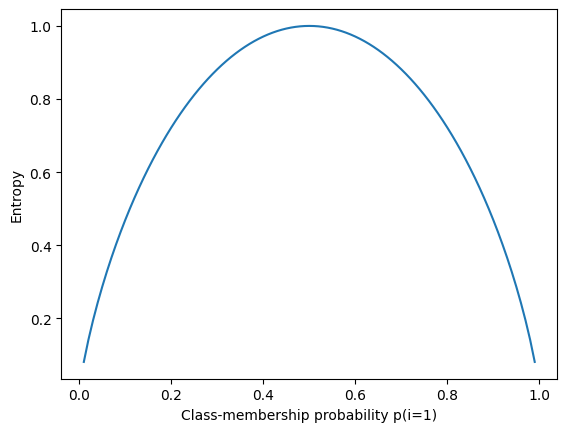

In [4]:
rt numpy as np
import matplotlib.pyplot as plt

def entropy(p):
     return - np.log2(p) - (1 - p) * np.log - p))

x = np.arange(0.0, 1.0, 0.01)
ent = [entro) if p != 0 else None p in x]

plt.ylabel('Entropy')
plt.xlabel('Class-mrship probability p(i=1)')
plt.plot(x, ent)
plt.show()

### 2. Plot impurity indices for the probability range [0, 1] for class 1.

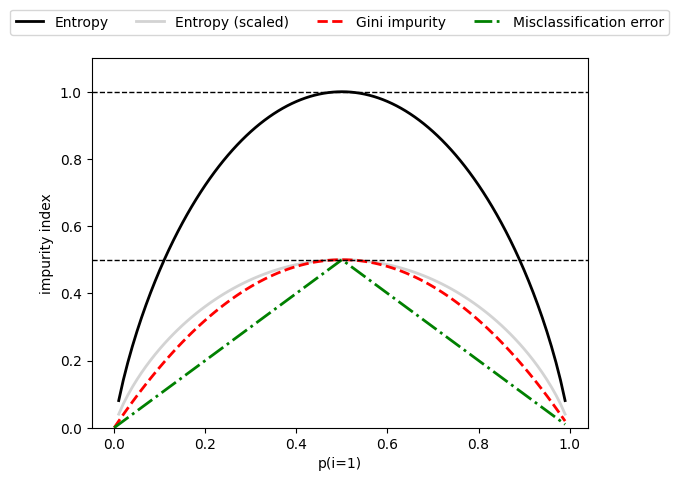

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def gini(p):
    return p*(1 - p) + (1 - p)*(1 - (1-p))

def entropy(p):
    return - p*np.log2(p) - (1 - p)*np.log2((1 - p))

def error(p):
    return 1 - np.max([p, 1 - p])

x = np.arange(0.0, 1.0, 0.01)
ent = [entropy(p) if p != 0 else None for p in x]
sc_ent = [e*0.5 if e else None for e in ent]
err = [error(i) for i in x]

fig = plt.figure()
ax = plt.subplot(111)
for i, lab, ls, c, in zip([ent, sc_ent, gini(x), err],
                          ['Entropy', 'Entropy (scaled)',
                           'Gini impurity',
                           'Misclassification error'],
                          ['-', '-', '--', '-.'],
                          ['black', 'lightgray',
                           'red', 'green', 'cyan']):
    line = ax.plot(x, i, label=lab,
                  linestyle=ls, lw=2, color=c)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          ncol=5, fancybox=True, shadow=False)

ax.axhline(y=0.5, linewidth=1, color='k', linestyle='--')
ax.axhline(y=1.0, linewidth=1, color='k', linestyle='--')
plt.ylim([0, 1.1])
plt.xlabel('p(i=1)')
plt.ylabel('impurity index')
plt.show()

